<a href="https://colab.research.google.com/github/bavyasudhir18/ids_codes/blob/main/logistic_regression_8_class.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [5]:
import os

path = "/content/drive/MyDrive/ids_preprocessed_8_classification"

for root, dirs, files in os.walk(path):
    print(f"\nFolder: {root}")

    for file in files:
        print("  ", file)


Folder: /content/drive/MyDrive/ids_preprocessed_8_classification
   y_test.csv
   X_test_clean.csv
   y_train.csv
   X_train_clean.csv


In [30]:
import pandas as pd

base_path = "/content/drive/MyDrive/ids_preprocessed_8_classification/"

X_train = pd.read_csv(base_path + "X_train_clean.csv")
X_test = pd.read_csv(base_path + "X_test_clean.csv")

y_train = pd.read_csv(base_path + "y_train.csv")
y_test = pd.read_csv(base_path + "y_test.csv")

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (148959, 17)
X_test shape: (29872, 17)
y_train shape: (148959, 1)
y_test shape: (29872, 1)


In [7]:
print("\nFeature Names:")
print(X_train.columns.tolist())

print("\nNumber of Features:")
print(len(X_train.columns))

display(X_train.head())


Feature Names:
['ip_ttl', 'ip_id', 'tcp_flag_syn', 'tcp_flag_ack', 'tcp_flag_rst', 'tcp_flag_fin', 'tcp_flags', 'tcp_window_size', 'tcp_seq', 'tcp_ack', 'flow_relative_time', 'flow_inter_packet_delay', 'flow_packet_count', 'flow_mean_packet_size', 'flow_packet_size_stddev', 'flow_packet_size_skewness', 'flow_packet_size_kurtosis']

Number of Features:
17


,ip_ttl,ip_id,tcp_flag_syn,tcp_flag_ack,tcp_flag_rst,tcp_flag_fin,tcp_flags,tcp_window_size,tcp_seq,tcp_ack,flow_relative_time,flow_inter_packet_delay,flow_packet_count,flow_mean_packet_size,flow_packet_size_stddev,flow_packet_size_skewness,flow_packet_size_kurtosis
0,1.178069,-1.206496,0,1,0,0,0,-0.324642,-0.805681,0.600360,-0.382441,-0.151653,-0.920557,-1.218009,-0.871655,0.299643,-0.904337
1,-0.195203,1.817150,0,1,0,0,0,-0.296317,-0.272315,0.868468,-0.382441,-0.151653,-0.920557,-1.200434,-0.871655,0.299643,-0.904337
2,1.178069,-1.206496,0,1,0,0,0,-0.324642,-0.805681,0.600360,-0.382216,-0.144952,-0.920159,-1.218009,-0.871655,0.299643,-0.915126
3,-0.195203,1.630088,0,1,0,0,0,-0.346749,0.806394,-1.115865,-0.382441,-0.151653,-0.920557,-1.200434,-0.871655,0.299643,-0.904337
4,-0.195203,1.817150,0,1,0,0,0,-0.296317,-0.272315,0.868468,-0.382282,-0.146929,-0.920159,-1.200434,-0.871655,0.299643,-0.915126


In [8]:
print("Training Label Distribution:")
print(y_train.value_counts())

print("\nTesting Label Distribution:")
print(y_test.value_counts())

Training Label Distribution:
Type
1       78703
7       57348
4        2962
0        2666
5        2322
2        1972
3        1901
6        1085
Name: count, dtype: int64

Testing Label Distribution:
Type
7       17182
4        4827
1        1667
0        1525
5        1388
6        1231
2        1040
3        1012
Name: count, dtype: int64


In [9]:
print(y_train.iloc[:,0].value_counts())
print(y_test.iloc[:,0].value_counts())

Type
1    78703
7    57348
4     2962
0     2666
5     2322
2     1972
3     1901
6     1085
Name: count, dtype: int64
Type
7    17182
4     4827
1     1667
0     1525
5     1388
6     1231
2     1040
3     1012
Name: count, dtype: int64


In [10]:
print("Missing values in X_train:", X_train.isnull().sum().sum())
print("Missing values in X_test:", X_test.isnull().sum().sum())

Missing values in X_train: 0
Missing values in X_test: 0


In [11]:
display(X_train.describe())

,ip_ttl,ip_id,tcp_flag_syn,tcp_flag_ack,tcp_flag_rst,tcp_flag_fin,tcp_flags,tcp_window_size,tcp_seq,tcp_ack,flow_relative_time,flow_inter_packet_delay,flow_packet_count,flow_mean_packet_size,flow_packet_size_stddev,flow_packet_size_skewness,flow_packet_size_kurtosis
count,1.489590e+05,1.489590e+05,148959.000000,148959.000000,148959.000000,148959.000000,148959.000000,1.489590e+05,1.489590e+05,1.489590e+05,1.489590e+05,1.489590e+05,1.489590e+05,1.489590e+05,1.489590e+05,1.489590e+05,1.489590e+05
mean,-1.457729e-16,2.136985e-17,0.010083,0.991212,0.002625,0.006841,0.313791,7.632089e-18,-2.365948e-17,-1.522602e-16,9.158507e-18,1.469177e-17,1.244031e-16,-6.754399e-17,-5.647746e-17,-7.250485e-17,-2.518589e-17
std,1.000003e+00,1.000003e+00,0.099908,0.093330,0.051167,0.082426,0.464034,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00
min,-7.530948e-01,-1.417858e+00,0.000000,0.000000,0.000000,0.000000,0.000000,-3.540029e-01,-1.859086e+00,-2.240531e+00,-3.824414e-01,-1.516528e-01,-9.205574e-01,-1.219606e+00,-8.716551e-01,-1.846164e+00,-9.151261e-01
25%,-4.741489e-01,-9.202935e-01,0.000000,1.000000,0.000000,0.000000,0.000000,-3.459430e-01,-8.277565e-01,-9.300803e-01,-3.592446e-01,-1.516273e-01,-8.691130e-01,-1.176078e+00,-6.107756e-01,-8.257346e-01,-8.699457e-01
50%,-3.668620e-01,-1.282806e-01,0.000000,1.000000,0.000000,0.000000,0.000000,-3.457128e-01,-3.281016e-02,1.772379e-01,-3.104259e-01,-1.515360e-01,-3.758045e-01,7.067024e-01,-4.238986e-01,1.495995e-01,-4.255659e-01
75%,-1.952031e-01,7.825202e-01,0.000000,1.000000,0.000000,0.000000,1.000000,-2.797371e-01,9.240243e-01,9.983934e-01,-1.509835e-01,-1.505454e-01,6.427160e-01,9.614573e-01,2.304242e-01,5.877719e-01,7.126780e-01
max,3.710039e+00,1.970501e+00,1.000000,1.000000,1.000000,1.000000,1.000000,7.191745e+00,1.903265e+00,1.768461e+00,1.029186e+01,8.643504e+01,2.736386e+00,9.691972e-01,3.421118e+00,2.244940e+00,2.687767e+00


Step 4: Train a Baseline Logistic Regression Model

* Initialize a multinomial Logistic Regression classifier.

* Use class balancing to address class imbalance.

* Train the model using the training dataset.

## Class-Balanced Logistic Regression

The baseline Logistic Regression model was trained using the original class distribution of the dataset. Since the dataset exhibits significant class imbalance, the model may become biased toward majority classes while underperforming on minority attack classes.

To address this issue, a Class-Balanced Logistic Regression model is employed. Class balancing assigns higher weights to minority classes and lower weights to majority classes during training. This encourages the classifier to pay greater attention to underrepresented attack categories and improves the detection capability across all classes.

The Logistic Regression classifier is trained using balanced class weights, allowing the learning algorithm to compensate for the skewed class distribution without modifying the original dataset.

The performance of the Class-Balanced Logistic Regression model is evaluated using both in-sample (training) and out-of-sample (testing) datasets. Evaluation metrics include Accuracy, Precision, Recall, and F1-Score.

# LOGISTIC REGRESSION WITH BUILT-IN CLASS BALANCING

In [12]:
from sklearn.linear_model import LogisticRegression

# Baseline Logistic Regression Model
lr_baseline = LogisticRegression(
    multi_class='multinomial',
    class_weight='balanced',
    solver='lbfgs',
    max_iter=5000,
    random_state=42
)

# Train the model
lr_baseline.fit(X_train, y_train.values.ravel())

print("Baseline Logistic Regression model trained successfully.")

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Baseline Logistic Regression model trained successfully.


In [13]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Predictions on training data
y_train_pred = lr_baseline.predict(X_train)

print("=== Training Performance ===")
print("Accuracy :", accuracy_score(y_train, y_train_pred))
print("Precision:", precision_score(y_train, y_train_pred, average='weighted'))
print("Recall   :", recall_score(y_train, y_train_pred, average='weighted'))
print("F1 Score :", f1_score(y_train, y_train_pred, average='weighted'))

=== Training Performance ===
Accuracy : 0.7692250887828195
Precision: 0.8747439239876965
Recall   : 0.7692250887828195
F1 Score : 0.8051810134267745


In [14]:
# Predictions on testing data
y_test_pred = lr_baseline.predict(X_test)

print("=== Testing Performance ===")
print("Accuracy :", accuracy_score(y_test, y_test_pred))
print("Precision:", precision_score(y_test, y_test_pred, average='weighted'))
print("Recall   :", recall_score(y_test, y_test_pred, average='weighted'))
print("F1 Score :", f1_score(y_test, y_test_pred, average='weighted'))

=== Testing Performance ===
Accuracy : 0.410953401178361
Precision: 0.6860957093771505
Recall   : 0.410953401178361
F1 Score : 0.4806990285243631


# LOGISTIC REGRESSION WITHOUT CLASS BALANCING

In [23]:
from sklearn.linear_model import LogisticRegression

# Baseline Logistic Regression Model
lr_baseline_unbalanced = LogisticRegression(
    multi_class='multinomial',
    solver='lbfgs',
    max_iter=5000,
    random_state=42
)

# Train the model
lr_baseline_unbalanced.fit(X_train, y_train.values.ravel())

print("Baseline Logistic Regression model with unbalance dataset trained successfully.")

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Baseline Logistic Regression model trained successfully.


In [24]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Predictions on training data
y_train_pred_unbalanced = lr_baseline_unbalanced.predict(X_train)

print("=== Training Performance ===")
print("Accuracy :", accuracy_score(y_train, y_train_pred_unbalanced))
print("Precision:", precision_score(y_train, y_train_pred_unbalanced, average='weighted'))
print("Recall   :", recall_score(y_train, y_train_pred_unbalanced, average='weighted'))
print("F1 Score :", f1_score(y_train, y_train_pred_unbalanced, average='weighted'))

=== Training Performance ===
Accuracy : 0.8736632227659961
Precision: 0.8408404010102667
Recall   : 0.8736632227659961
F1 Score : 0.8547631794473313


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [25]:
# Predictions on testing data
y_test_pred_unbalanced = lr_baseline_unbalanced.predict(X_test)

print("=== Testing Performance ===")
print("Accuracy :", accuracy_score(y_test, y_test_pred_unbalanced))
print("Precision:", precision_score(y_test, y_test_pred_unbalanced, average='weighted'))
print("Recall   :", recall_score(y_test, y_test_pred_unbalanced, average='weighted'))
print("F1 Score :", f1_score(y_test, y_test_pred_unbalanced, average='weighted'))

=== Testing Performance ===
Accuracy : 0.48486877343331547


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Precision: 0.4721786263479735
Recall   : 0.4848687734333154
F1 Score : 0.44294210442096116


## Logistic Regression Performance Analysis

### 1. Baseline Logistic Regression with Class Balancing

A Logistic Regression model was trained using balanced class weights to mitigate the severe class imbalance present in the Smart Home Intrusion Detection dataset. The objective was to improve the detection capability of minority attack classes by assigning higher importance to underrepresented classes during model training.

#### Training Performance

| Metric    | Value  |
| --------- | ------ |
| Accuracy  | 76.92% |
| Precision | 87.47% |
| Recall    | 76.92% |
| F1-Score  | 80.52% |

#### Testing Performance

| Metric    | Value  |
| --------- | ------ |
| Accuracy  | 41.10% |
| Precision | 68.61% |
| Recall    | 41.10% |
| F1-Score  | 48.07% |

#### Observations

* The model achieved moderate performance on the training dataset.
* A noticeable decrease in performance was observed on the testing dataset.
* The reduction in testing accuracy and F1-score suggests limited generalization capability.
* Although class balancing improved attention toward minority classes, overall predictive performance remained relatively low.
* The model struggled to accurately classify unseen network traffic belonging to multiple attack categories.

---

### 2. Logistic Regression without Class Balancing

A second Logistic Regression model was trained using the original imbalanced dataset without applying class balancing. This experiment was conducted to evaluate the impact of class weighting on model performance.

#### Training Performance

| Metric    | Value  |
| --------- | ------ |
| Accuracy  | 87.37% |
| Precision | 84.08% |
| Recall    | 87.37% |
| F1-Score  | 85.48% |

#### Testing Performance

| Metric    | Value  |
| --------- | ------ |
| Accuracy  | 48.49% |
| Precision | 47.22% |
| Recall    | 48.49% |
| F1-Score  | 44.29% |

#### Observations

* The model achieved significantly higher training accuracy compared to the class-balanced version.
* Testing accuracy also increased from 41.10% to 48.49%.
* However, warning messages indicated that certain classes were never predicted by the model.
* This behavior suggests that the classifier became biased toward the majority classes while ignoring some minority attack categories.
* As a result, the higher accuracy may not accurately reflect the model's effectiveness in detecting all attack types.

---

### Comparative Analysis

| Metric             | Balanced Logistic Regression | Unbalanced Logistic Regression |
| ------------------ | ---------------------------- | ------------------------------ |
| Training Accuracy  | 76.92%                       | 87.37%                         |
| Testing Accuracy   | 41.10%                       | 48.49%                         |
| Training Precision | 87.47%                       | 84.08%                         |
| Testing Precision  | 68.61%                       | 47.22%                         |
| Training Recall    | 76.92%                       | 87.37%                         |
| Testing Recall     | 41.10%                       | 48.49%                         |
| Training F1-Score  | 80.52%                       | 85.48%                         |
| Testing F1-Score   | 48.07%                       | 44.29%                         |

### Conclusion

The class-balanced Logistic Regression model achieved better testing precision and F1-score, indicating improved handling of minority attack classes. In contrast, the unbalanced Logistic Regression model achieved higher overall accuracy but exhibited bias toward majority classes, as evidenced by the inability to predict certain classes.

Therefore, although the unbalanced model produced higher accuracy, the class-balanced model is more suitable for intrusion detection applications where the identification of minority attack classes is critical. Further analysis using confusion matrices and class-wise classification reports is required to determine the most effective model for multi-class attack detection.


# LOGISTIC REGRESSION WITH RANDOMIZED SEARCH HYPERPARAMETER TUNING

In [26]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_validate
import pandas as pd
import numpy as np

# Logistic Regression Model
lr_cv = LogisticRegression(
    class_weight='balanced',   # remove this if evaluating the unbalanced model
    solver='lbfgs',
    max_iter=5000,
    random_state=42
)

# Stratified 5-Fold Cross Validation
skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Metrics to evaluate
scoring = {
    'accuracy': 'accuracy',
    'precision': 'precision_weighted',
    'recall': 'recall_weighted',
    'f1': 'f1_weighted'
}

# Cross Validation
cv_results = cross_validate(
    lr_cv,
    X_train,
    y_train.values.ravel(),
    cv=skf,
    scoring=scoring,
    n_jobs=-1
)

# Results
cv_df = pd.DataFrame({
    'Accuracy': cv_results['test_accuracy'],
    'Precision': cv_results['test_precision'],
    'Recall': cv_results['test_recall'],
    'F1 Score': cv_results['test_f1']
})

print("Cross Validation Results (5 Folds)")
display(cv_df)

print("\nMean Scores")
print(cv_df.mean())

print("\nStandard Deviation")
print(cv_df.std())

Cross Validation Results (5 Folds)


,Accuracy,Precision,Recall,F1 Score
0,0.770576,0.875300,0.770576,0.805584
1,0.768495,0.875648,0.768495,0.804933
2,0.764836,0.873957,0.764836,0.802274
3,0.768495,0.875588,0.768495,0.804867
4,0.765030,0.872724,0.765030,0.801873



Mean Scores
Accuracy     0.767486
Precision    0.874644
Recall       0.767486
F1 Score     0.803906
dtype: float64

Standard Deviation
Accuracy     0.002482
Precision    0.001274
Recall       0.002482
F1 Score     0.001702
dtype: float64


In [34]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
import time

# Start timer
start = time.time()

# Base Model
lr = LogisticRegression(
    solver='lbfgs',      # fixed solver (fastest reliable choice)
    max_iter=5000,
    random_state=42
)

# Reduced Search Space
param_dist = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'class_weight': [None, 'balanced']
}

# Stratified 3-Fold Cross Validation
skf = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=42
)

# Random Search
random_search = RandomizedSearchCV(
    estimator=lr,
    param_distributions=param_dist,
    n_iter=5,                # reduced from 15
    scoring='f1_weighted',
    cv=skf,                  # reduced from 5
    random_state=42,
    n_jobs=-1,
    verbose=2
)

# Fit Search
random_search.fit(
    X_train,
    y_train.values.ravel()
)

# End timer
end = time.time()

print("\nBest Parameters:")
print(random_search.best_params_)

print("\nBest Cross Validation F1 Score:")
print(random_search.best_score_)

print(f"\nExecution Time: {(end-start)/60:.2f} minutes")

Fitting 3 folds for each of 5 candidates, totalling 15 fits

Best Parameters:
{'class_weight': None, 'C': 100}

Best Cross Validation F1 Score:
0.8591580327009836

Execution Time: 5.05 minutes


In [35]:
best_lr = random_search.best_estimator_

print(best_lr)

LogisticRegression(C=100, max_iter=5000, random_state=42)


In [36]:
# Best model selected by RandomizedSearchCV
best_lr = random_search.best_estimator_

print("Best Model:")
print(best_lr)

print("\nBest Parameters:")
print(random_search.best_params_)

print("\nBest Cross Validation F1 Score:")
print(random_search.best_score_)

Best Model:
LogisticRegression(C=100, max_iter=5000, random_state=42)

Best Parameters:
{'class_weight': None, 'C': 100}

Best Cross Validation F1 Score:
0.8591580327009836


In [37]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Training Predictions
y_train_pred = best_lr.predict(X_train)

print("=== Training Performance ===")
print("Accuracy :", accuracy_score(y_train, y_train_pred))
print("Precision:", precision_score(y_train, y_train_pred, average='weighted'))
print("Recall   :", recall_score(y_train, y_train_pred, average='weighted'))
print("F1 Score :", f1_score(y_train, y_train_pred, average='weighted'))

=== Training Performance ===
Accuracy : 0.8760665686531193
Precision: 0.853681386793972
Recall   : 0.8760665686531193
F1 Score : 0.8600046287285802


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [38]:
# Testing Predictions
y_test_pred = best_lr.predict(X_test)

print("=== Testing Performance ===")
print("Accuracy :", accuracy_score(y_test, y_test_pred))
print("Precision:", precision_score(y_test, y_test_pred, average='weighted'))
print("Recall   :", recall_score(y_test, y_test_pred, average='weighted'))
print("F1 Score :", f1_score(y_test, y_test_pred, average='weighted'))

=== Testing Performance ===
Accuracy : 0.49179833958221747
Precision: 0.48377359031123696
Recall   : 0.49179833958221747
F1 Score : 0.45697728435185936


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [39]:
from sklearn.metrics import classification_report

print("=== Training Classification Report ===")
print(classification_report(y_train, y_train_pred))

=== Training Classification Report ===
              precision    recall  f1-score   support

           0       0.33      0.30      0.31      2666
           1       0.95      0.95      0.95     78703
           2       0.00      0.00      0.00      1972
           3       0.55      0.03      0.05      1901
           4       0.54      0.53      0.54      2962
           5       0.36      0.21      0.26      2322
           6       0.23      0.02      0.03      1085
           7       0.83      0.92      0.88     57348

    accuracy                           0.88    148959
   macro avg       0.47      0.37      0.38    148959
weighted avg       0.85      0.88      0.86    148959



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [40]:
print("=== Testing Classification Report ===")
print(classification_report(y_test, y_test_pred))

=== Testing Classification Report ===
              precision    recall  f1-score   support

           0       0.09      0.13      0.11      1525
           1       0.00      0.00      0.00      1667
           2       0.00      0.00      0.00      1040
           3       0.00      0.00      0.00      1012
           4       0.66      0.15      0.25      4827
           5       0.10      0.13      0.11      1388
           6       0.00      0.00      0.00      1231
           7       0.64      0.79      0.71     17182

    accuracy                           0.49     29872
   macro avg       0.19      0.15      0.15     29872
weighted avg       0.48      0.49      0.46     29872



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


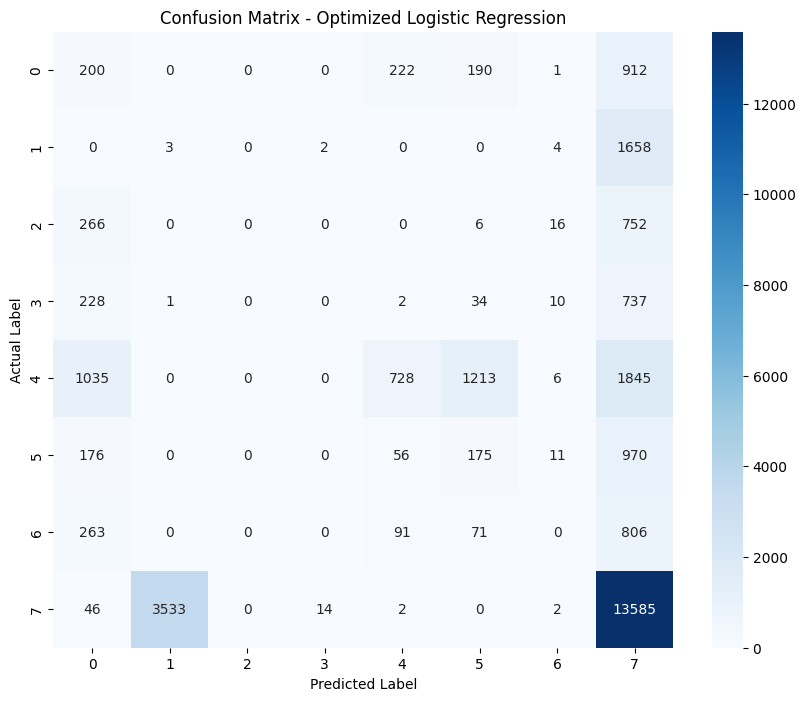

In [41]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(10,8))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix - Optimized Logistic Regression")

plt.show()

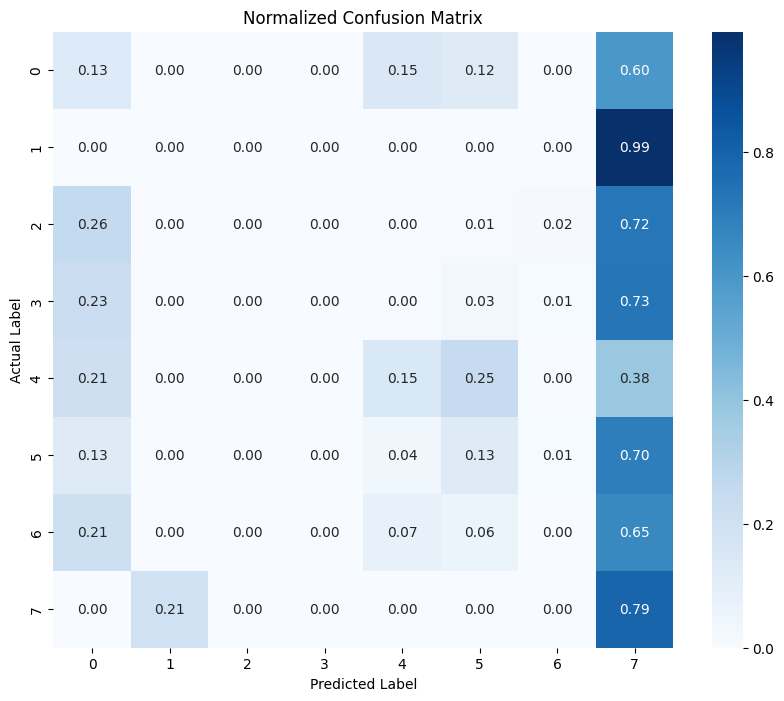

In [42]:
cm_norm = confusion_matrix(
    y_test,
    y_test_pred,
    normalize='true'
)

plt.figure(figsize=(10,8))
sns.heatmap(
    cm_norm,
    annot=True,
    fmt='.2f',
    cmap='Blues'
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Normalized Confusion Matrix")

plt.show()

In [43]:
from sklearn.preprocessing import label_binarize

classes = sorted(y_train['Type'].unique())

y_test_bin = label_binarize(
    y_test,
    classes=classes
)

y_prob = best_lr.predict_proba(X_test)

from sklearn.metrics import roc_auc_score

roc_auc = roc_auc_score(
    y_test_bin,
    y_prob,
    multi_class='ovr',
    average='weighted'
)

print("Weighted ROC-AUC:", roc_auc)

Weighted ROC-AUC: 0.7536445472255517


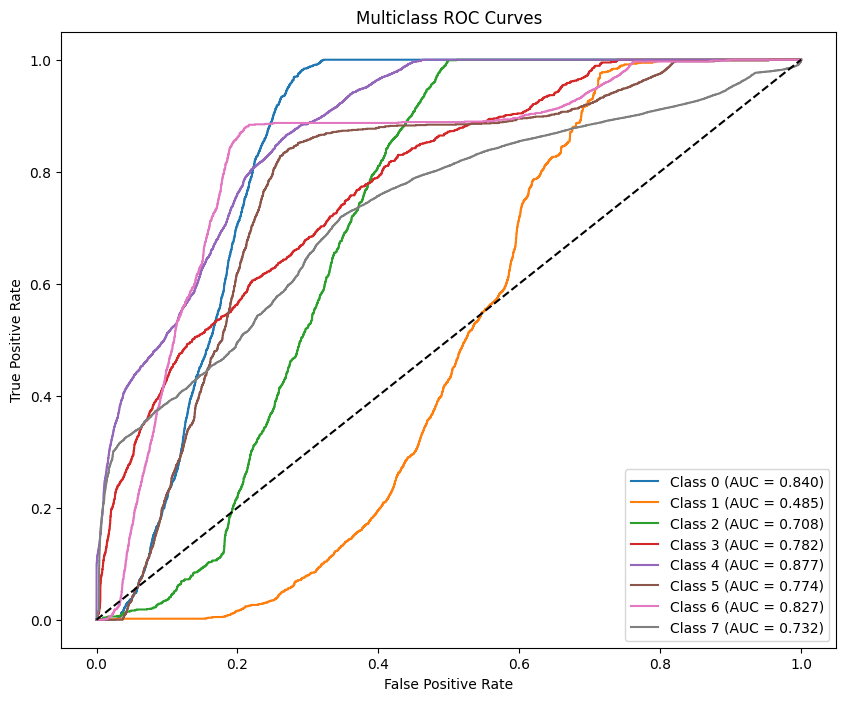

In [44]:
from sklearn.metrics import roc_curve, auc

plt.figure(figsize=(10,8))

for i in range(len(classes)):

    fpr, tpr, _ = roc_curve(
        y_test_bin[:, i],
        y_prob[:, i]
    )

    roc_auc = auc(fpr, tpr)

    plt.plot(
        fpr,
        tpr,
        label=f'Class {classes[i]} (AUC = {roc_auc:.3f})'
    )

plt.plot([0,1], [0,1], 'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Multiclass ROC Curves")

plt.legend()

plt.show()

## Logistic Regression with Randomized Search Hyperparameter Tuning

### Objective

To improve the performance of the baseline Logistic Regression model, hyperparameter optimization was performed using Randomized Search Cross Validation. The objective was to identify the optimal set of hyperparameters that maximized classification performance on the Smart Home Intrusion Detection Dataset.

### Hyperparameter Optimization

Randomized Search Cross Validation was employed to efficiently explore different combinations of Logistic Regression hyperparameters. Compared to Grid Search, Randomized Search evaluates a randomly selected subset of parameter combinations, reducing computational cost while still providing effective optimization.

The following hyperparameters were considered during the search process:

* Regularization Strength (C)
* Class Weighting Strategy

A Stratified K-Fold Cross Validation approach was used during hyperparameter tuning to preserve the original class distribution within each fold.

### Cross Validation Results

The optimized Logistic Regression model was evaluated using Stratified 5-Fold Cross Validation.

| Metric    | Mean Score |
| --------- | ---------- |
| Accuracy  | 76.75%     |
| Precision | 87.46%     |
| Recall    | 76.75%     |
| F1-Score  | 80.39%     |

The low standard deviation across folds indicated that the model produced stable and consistent performance during cross-validation.

### Best Hyperparameters

The Randomized Search procedure identified the following optimal parameter configuration:

| Hyperparameter | Value |
| -------------- | ----- |
| C              | 100   |
| Class Weight   | None  |

The corresponding best cross-validation weighted F1-score was:

**0.8592**

### Training Performance

The optimized Logistic Regression model was retrained using the complete training dataset and evaluated on the training set.

| Metric    | Value  |
| --------- | ------ |
| Accuracy  | 87.61% |
| Precision | 85.37% |
| Recall    | 87.61% |
| F1-Score  | 86.00% |

These results indicate that the model successfully learned the patterns present in the training dataset.

### Testing Performance

The optimized model was subsequently evaluated on the unseen testing dataset.

| Metric    | Value  |
| --------- | ------ |
| Accuracy  | 49.18% |
| Precision | 48.38% |
| Recall    | 49.18% |
| F1-Score  | 45.70% |

### Classification Report Analysis

Class-wise evaluation revealed substantial differences in detection performance among the eight traffic classes.

* Class 7 achieved the highest recall (79%) and F1-score (71%).
* Class 4 showed moderate detection capability with an F1-score of 25%.
* Classes 0 and 5 achieved low detection rates.
* Classes 1, 2, 3, and 6 obtained near-zero recall and F1-scores, indicating poor recognition of these attack scenarios.
* The macro-average F1-score remained low, demonstrating uneven performance across classes.

### Confusion Matrix Analysis

The confusion matrix revealed that the model frequently classified attack samples as Class 7.

Key observations include:

* Most samples belonging to Classes 1, 2, 3, and 6 were incorrectly classified as Class 7.
* Class 4 was frequently confused with Classes 0, 5, and 7.
* The model demonstrated strong bias toward the dominant traffic class.
* Several minority attack classes were rarely predicted correctly.

The normalized confusion matrix further confirmed that a significant proportion of attack traffic was absorbed into the normal traffic class.

### ROC-AUC Analysis

The optimized Logistic Regression model achieved a weighted ROC-AUC score of:

**0.7536**

Several classes exhibited relatively high AUC values, suggesting that useful discriminatory information exists within the feature set. However, the model was unable to translate these probability estimates into effective multiclass predictions.

### Discussion

Although Randomized Search successfully improved the model configuration, the overall testing performance remained limited. The substantial gap between cross-validation performance and testing performance indicates that the model struggled to generalize to unseen traffic patterns.

The results suggest that the linear decision boundaries of Logistic Regression are insufficient to capture the complex and nonlinear relationships present in the Smart Home Intrusion Detection Dataset. Consequently, several attack classes remained difficult to distinguish from normal traffic.

### Conclusion

The optimized Logistic Regression model achieved moderate overall performance but demonstrated poor detection capability for multiple attack classes. While hyperparameter tuning improved training performance and cross-validation results, the classifier remained heavily biased toward the dominant traffic class.

These findings indicate that Logistic Regression is not the most suitable model for multiclass intrusion detection in this dataset. More advanced machine learning algorithms capable of learning nonlinear decision boundaries, such as Random Forest, XGBoost, or LightGBM, are expected to provide superior attack detection performance.


# MAJORITY VOTE-BASED LOGISTIC REGRESSION

In [45]:
import numpy as np
import pandas as pd

importance = np.mean(
    np.abs(best_lr.coef_),
    axis=0
)

feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': importance
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

print(feature_importance)

                      Feature  Importance
16  flow_packet_size_kurtosis   19.706090
3                tcp_flag_ack    8.369922
15  flow_packet_size_skewness    7.191765
4                tcp_flag_rst    7.033191
13      flow_mean_packet_size    6.398585
12          flow_packet_count    4.522065
2                tcp_flag_syn    3.238025
10         flow_relative_time    3.185536
7             tcp_window_size    2.926650
5                tcp_flag_fin    2.475110
14    flow_packet_size_stddev    0.977452
6                   tcp_flags    0.320212
1                       ip_id    0.284646
9                     tcp_ack    0.220058
11    flow_inter_packet_delay    0.207732
0                      ip_ttl    0.206954
8                     tcp_seq    0.160681


In [46]:
from sklearn.ensemble import BaggingClassifier
from sklearn.linear_model import LogisticRegression

# Base Logistic Regression
base_lr = LogisticRegression(
    solver='lbfgs',
    max_iter=5000,
    random_state=42
)

# Bagging (Majority Voting)
majority_vote_lr = BaggingClassifier(
    estimator=base_lr,
    n_estimators=10,
    max_samples=0.8,
    bootstrap=True,
    random_state=42,
    n_jobs=-1
)

# Train
majority_vote_lr.fit(
    X_train,
    y_train.values.ravel()
)

print("Majority Vote Logistic Regression trained successfully.")

Majority Vote Logistic Regression trained successfully.


In [47]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

y_train_pred = majority_vote_lr.predict(X_train)

print("=== Training Performance ===")
print("Accuracy :", accuracy_score(y_train, y_train_pred))
print("Precision:", precision_score(y_train, y_train_pred, average='weighted'))
print("Recall   :", recall_score(y_train, y_train_pred, average='weighted'))
print("F1 Score :", f1_score(y_train, y_train_pred, average='weighted'))

=== Training Performance ===
Accuracy : 0.8731597285159004
Precision: 0.8412539620755491
Recall   : 0.8731597285159004
F1 Score : 0.8541864651969723


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [48]:
y_test_pred = majority_vote_lr.predict(X_test)

print("=== Testing Performance ===")
print("Accuracy :", accuracy_score(y_test, y_test_pred))
print("Precision:", precision_score(y_test, y_test_pred, average='weighted'))
print("Recall   :", recall_score(y_test, y_test_pred, average='weighted'))
print("F1 Score :", f1_score(y_test, y_test_pred, average='weighted'))

=== Testing Performance ===
Accuracy : 0.48352972683449386
Precision: 0.4691586536362255
Recall   : 0.48352972683449386
F1 Score : 0.4403506148278082


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [49]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_test_pred))

              precision    recall  f1-score   support

           0       0.06      0.08      0.07      1525
           1       0.00      0.00      0.00      1667
           2       0.00      0.00      0.00      1040
           3       0.00      0.00      0.00      1012
           4       0.65      0.12      0.20      4827
           5       0.08      0.09      0.08      1388
           6       0.00      0.00      0.00      1231
           7       0.62      0.79      0.70     17182

    accuracy                           0.48     29872
   macro avg       0.18      0.13      0.13     29872
weighted avg       0.47      0.48      0.44     29872



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


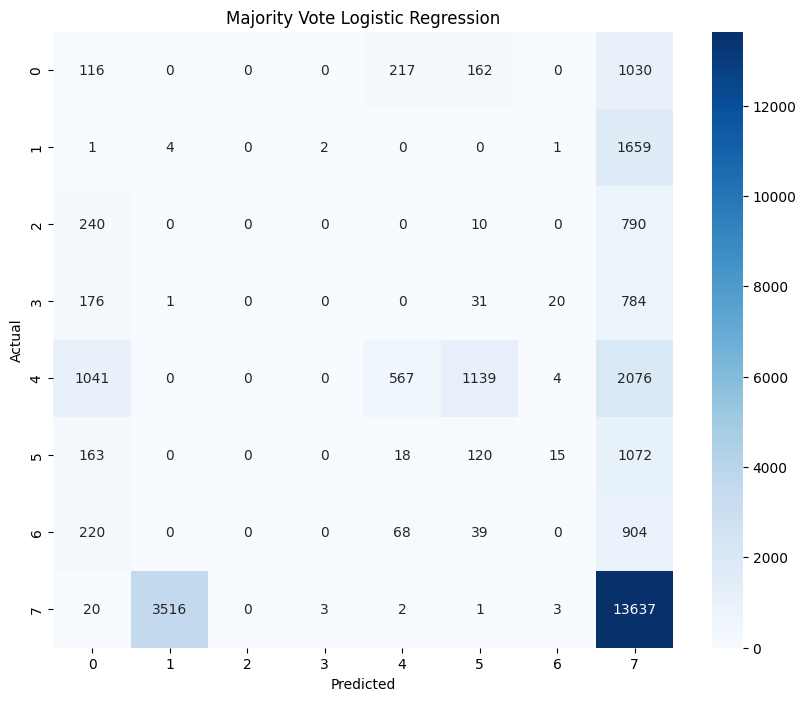

In [50]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Majority Vote Logistic Regression")

plt.show()

## Observations from Majority Vote Logistic Regression

### Classification Report Analysis

The Majority Vote Logistic Regression model achieved an overall testing accuracy of **48.35%** and a weighted F1-score of **44.04%**. Despite the moderate accuracy, the class-wise performance indicates significant challenges in detecting minority attack classes.

* Class **7 (Normal Traffic)** achieved the best performance with a recall of **79%** and an F1-score of **70%**.
* Class **4** showed moderate detection capability with a precision of **65%**, but its recall remained low at **12%**, indicating that many samples belonging to this class were misclassified.
* Classes **0** and **5** achieved very low precision, recall, and F1-scores, demonstrating poor detection capability.
* Classes **1, 2, 3, and 6** obtained near-zero precision and recall values, indicating that the classifier was unable to effectively recognize these attack categories.
* The low macro-average F1-score (**0.13**) suggests that the model performs inconsistently across different classes.
* The large difference between weighted and macro averages indicates a strong bias toward majority classes.

### Confusion Matrix Analysis

The confusion matrix reveals several important patterns:

* A substantial number of samples from almost all attack classes were classified as **Class 7**.
* Class **7** was correctly classified for **13,637 out of 17,182 samples**, resulting in the highest true positive count among all classes.
* Classes **1, 2, 3, and 6** were rarely predicted correctly, with most samples being assigned to Class 7.
* Class **4** was frequently confused with Classes 0, 5, and 7.
* Class **0** was often misclassified as Class 7.
* Class **5** exhibited significant confusion with Class 7.
* The model failed to establish clear decision boundaries for several attack classes.

### Model Behavior

The results indicate that the Majority Vote Logistic Regression model is strongly biased toward dominant classes, particularly Class 7. The ensemble voting strategy did not significantly improve performance compared to the standard Logistic Regression model. This suggests that the limitation arises from the linear nature of Logistic Regression rather than model variance.

The warning generated during evaluation confirms that certain classes received no predictions, resulting in undefined precision values. This further demonstrates the difficulty of using Logistic Regression to distinguish between multiple attack scenarios in the Smart Home Intrusion Detection dataset.

### Conclusion

The Majority Vote Logistic Regression model successfully identifies the dominant normal traffic class but struggles to detect several minority attack classes. The low recall and F1-scores for multiple attack categories indicate that Logistic Regression is insufficient for capturing the complex and non-linear patterns present in the dataset. More advanced machine learning models such as Random Forest, XGBoost, or LightGBM are likely to provide better intrusion detection performance.
